**Task 1: SVM**

In [2]:
# Files from task1_data folder 

import pandas as pd 

# Given features from specifications 
additional_features_df = pd.read_csv('task1_data/additional_features.csv')
# Colour histograms
color_histogram_df = pd.read_csv('task1_data/color_histogram.csv')
# HOG features reduced by PCA
hog_pca_df = pd.read_csv('task1_data/hog_pca.csv')
# Unchanged Test data
test_metadata_df = pd.read_csv('task1_data/test_metadata.csv')
# Unchanged Training data 
train_metadata_df = pd.read_csv('task1_data/train_metadata.csv')


In [2]:
# https://www.youtube.com/watch?v=7K-gnWlgAt8
# Extracting features from RESNET - doing own feature engineering 
import torch
from torchvision import models, transforms
import numpy
from PIL import Image
import os

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.eval()


transform_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )  
])

feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])
BASE_DIR = os.getcwd() + "/task1_data/"

def extract_features(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform_pipeline(image)
    image = image.unsqueeze(0)
    with torch.no_grad():
        features = feature_extractor(image)
    features = features.detach().numpy().flatten()
    return features 

features_list = []
for idx, row in train_metadata_df.iterrows():
    image_path = os.path.join(BASE_DIR, row["image_path"])
    feats = extract_features(image_path)
    features_list.append(feats)

features_df = pd.DataFrame(features_list, index=train_metadata_df["image_id"])




Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV accuracy: 0.9146666666666666
Test accuracy: 0.9146666666666666
F1 score: 0.9144515769179143


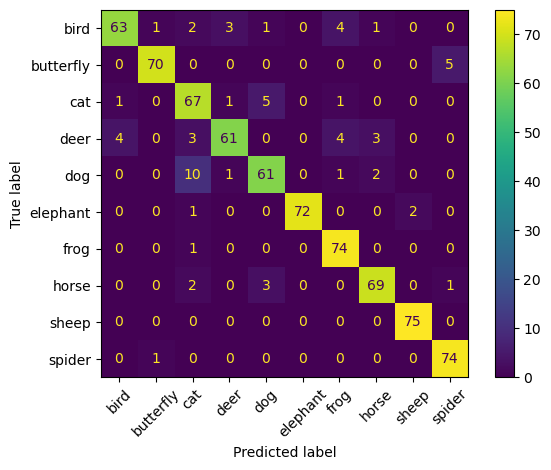

In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn import svm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Associate features with correct labels for training purposes 
additional_features_merged = pd.merge(train_metadata_df, features_df, on="image_id")

# Split into train and local test set
training_temp, local_test_set = train_test_split(
    additional_features_merged, 
    test_size=0.2, 
    random_state=42, 
    stratify=additional_features_merged["class_id"]
)

x_trained = training_temp.drop(columns=["image_id", "class_name", "image_path", "class_id"])
y_trained = training_temp["class_id"]
# Validation sets 
x_test = local_test_set.drop(columns=["image_id", "class_name", "image_path", "class_id"])
y_test = local_test_set["class_id"]

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'], 
    'gamma': ['scale', 'auto']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_model = GridSearchCV(
    svm.SVC(),
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

svm_model.fit(x_trained, y_trained)

print("Best parameters:", svm_model.best_params_)
print("Best CV accuracy:", svm_model.best_score_)

# Evaluate on local test set
local_predictions = svm_model.predict(x_test)

print("Test accuracy:", accuracy_score(y_test, local_predictions))
print("F1 score:", f1_score(y_test, local_predictions, average='macro'))

# Confusion matrix
class_names = additional_features_merged["class_name"].unique()
cm = confusion_matrix(y_test, local_predictions)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.savefig("confusion_matrix_svm.png", dpi=150)
plt.show()

# Predict on local test set and Kaggle
def predict_SVM(image_paths):
    specific_features = []
    for image_path in image_paths:
        image_path = os.path.join(BASE_DIR, image_path)
        specific_features.append(extract_features(image_path))
    predictions = svm_model.predict(specific_features)
    return predictions



In [4]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score

print("F1 Scores")
f1_svm = f1_score(y_test, local_predictions, average=None)
print(f1_svm)
print("Recall scores")
recall_svm = recall_score(y_test, local_predictions, average=None)
print(recall_svm)
print("Precision scores")
precision_svm = precision_score(y_test, local_predictions, average=None)
print(precision_svm)
print("Overall accuracy")
svm_accuracy = accuracy_score(y_test, local_predictions)
print(svm_accuracy)

F1 Scores
[0.88111888 0.95238095 0.83229814 0.86524823 0.84137931 0.97959184
 0.93081761 0.92       0.98684211 0.95483871]
Recall scores
[0.84       0.93333333 0.89333333 0.81333333 0.81333333 0.96
 0.98666667 0.92       1.         0.98666667]
Precision scores
[0.92647059 0.97222222 0.77906977 0.92424242 0.87142857 1.
 0.88095238 0.92       0.97402597 0.925     ]
Overall accuracy
0.9146666666666666


In [5]:
from sklearn.utils.multiclass import unique_labels
classes = unique_labels(y_test, local_predictions)
print(classes)

[0 1 2 3 4 5 6 7 8 9]


In [6]:
# Kaggle submission
kaggle_predictions_svm = predict_SVM(test_metadata_df["image_path"])
submission_df = pd.DataFrame({
    "image_id": test_metadata_df["image_id"],
    "class_id": kaggle_predictions_svm
})
submission_df.to_csv("submission_svm_new.csv", index=False)

**Task 1: Random Forest**

In [3]:

!pip install opencv-python
import os
import cv2
import numpy as np
from skimage import io, feature, img_as_ubyte
BASE_DIR = os.getcwd() + "/task1_data/"
from sklearn.cluster import KMeans

# https://dev.to/chidoziemanagwu/implementing-edge-detection-with-python-and-opencv-a-step-by-step-guide-57ab
# https://www.geeksforgeeks.org/machine-learning/image-feature-extraction-using-python/
# Doing edge detection

def process_image_edge_detection(filename):
    image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

    sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=5)

    magnitude = np.abs(sobelx)

    hist, _ = np.histogram(magnitude, bins=10, range=(0, np.max(magnitude)+1e-6))
    hist = hist / (np.sum(hist) + 1e-6)

    return np.concatenate([hist, [magnitude.mean(), magnitude.std()]])

# Detecting SIFT Features 
# SIFT stands for Scale-Invariant Feature Transform
# Aims to find and match unique points in images

def extract_SIFT(filename):
    image = cv2.imread(filename)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(gray, None)
    return descriptors

def build_vocabulary(descriptor_list):
    descriptor_list = [d for d in descriptor_list if d is not None]
    all_descriptors = np.vstack(descriptor_list)
    kmeans = KMeans(
        n_clusters=100,
        random_state=42,
        n_init=10
    )
    kmeans.fit(all_descriptors)
    return kmeans

def process_SIFT(filename, kmeans):
    descriptors = extract_SIFT(filename)
    k = kmeans.n_clusters
    hist = np.zeros(k)
    if descriptors is None:
        return hist
    clusters = kmeans.predict(descriptors)
    # Building a BoVW
    for c in clusters:
        hist[c] += 1
    if hist.sum() > 0:
        hist = hist / hist.sum()

    return hist


descriptor_list = []
for idx, row in train_metadata_df.iterrows():
    image_path = os.path.join(BASE_DIR, row["image_path"])
    desc = extract_SIFT(image_path)
    descriptor_list.append(desc)

kmeans = build_vocabulary(descriptor_list)
sift_features_list = []

for idx, row in train_metadata_df.iterrows():
    image_path = os.path.join(BASE_DIR, row["image_path"])
    feats = process_SIFT(image_path, kmeans)
    sift_features_list.append(feats)
columns = [f"sift_{i}" for i in range(100)]
sift_features_array = np.array(sift_features_list)

sift_df = pd.DataFrame(sift_features_array, columns=columns)
sift_df["class_id"] = train_metadata_df["class_id"].values

print(sift_df.shape)


# Extracting texture features
def process_texture(filename):
    image = io.imread(filename, as_gray=True)
    image = img_as_ubyte(image)
    lbp = feature.local_binary_pattern(image, P=8, R=1,method='uniform')
    n_bins = int(lbp.max() + 1)
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)
    return hist

edge_features_list = []
for idx, row in train_metadata_df.iterrows():
    image_path = os.path.join(BASE_DIR, row["image_path"])
    feats = process_image_edge_detection(image_path)
    edge_features_list.append(feats)

edge_features_array = np.array(edge_features_list)

num_features = edge_features_array.shape[1]
columns = [f"edge_{i}" for i in range(num_features)]

edge_df = pd.DataFrame(edge_features_array, columns=columns)
edge_df["class_id"] = train_metadata_df["class_id"].values





texture_features_list = []
for idx, row in train_metadata_df[0:3750].iterrows():
    image_path = os.path.join(BASE_DIR, row["image_path"])
    feats =  process_texture(image_path)
    texture_features_list.append(feats)
n_bins = len(texture_features_list[0])
columns = [f"texture_{i}" for i in range(n_bins)]
texture_df = pd.DataFrame(texture_features_list, columns=columns)
texture_df["class_id"] = train_metadata_df["class_id"].values
print(texture_df.shape)



    

(3750, 101)
(3750, 11)


In [ ]:
combined_features_df = pd.concat([
    additional_features_df[0:3750].drop(columns=["class_id"], errors="ignore").reset_index(drop=True),

    color_histogram_df[0:3750].drop(columns=["class_id"], errors="ignore").reset_index(drop=True),

    hog_pca_df[0:3750].drop(columns=["class_id"], errors="ignore").reset_index(drop=True),

    texture_df.drop(columns=["class_id"], errors="ignore").reset_index(drop=True),

    edge_df.drop(columns=["class_id"], errors="ignore").reset_index(drop=True),

    sift_df.drop(columns=["class_id"], errors="ignore").reset_index(drop=True)

], axis=1)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif

print(combined_features_df.columns)
X = combined_features_df.drop(columns=['image_id'])
y = train_metadata_df["class_id"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# Only compute mututal information for the training set to avoid leakage
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

mi_df = pd.DataFrame({
    "feature": X_train.columns,
    "mi_score": mi_scores
}).sort_values(by="mi_score", ascending=False)

# top_n = 120
# selected_features = mi_df["feature"].head(top_n).values


In [ ]:
# Handcrafted features + Random Forest 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score


top_n_values = [20, 50, 100, 150, 200]
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for n in top_n_values:

    selected_features = mi_df["feature"].head(n).values

    X_train_sel = X_train[selected_features]
    X_val_sel = X_val[selected_features]

    rf = RandomForestClassifier(
        n_estimators=600,
        max_depth=25,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=1
    )
    scores = cross_val_score(
        rf,
        X_train_sel,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=1
    )

    mean_acc = scores.mean()

    results.append((n, mean_acc))

    print(f"Top {n} features -> CV Accuracy: {mean_acc:.4f}")

best_n, best_acc = max(results, key=lambda x: x[1])

selected_features = mi_df["feature"].head(best_n).values
print("Best number of features:", best_n)
print("Best CV accuracy:", best_acc)
print(mi_df.head(20))


X_train_sel = X_train[selected_features]
X_val_sel = X_val[selected_features]

final_model = RandomForestClassifier(
    n_estimators=600,
    max_depth=25,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_sel, y_train)

y_pred = final_model.predict(X_val_sel)

print("Accuracy:", accuracy_score(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))

def predict_image_class(image_path, image_id):

    additional_feats = additional_features_df.set_index("image_id").loc[image_id]
    additional_feats = additional_feats.drop("class_id", errors="ignore")

    color_feats = color_histogram_df.set_index("image_id").loc[image_id]
    color_feats = color_feats.drop("class_id", errors="ignore")

    hog_feats = hog_pca_df.set_index("image_id").loc[image_id]
    hog_feats = hog_feats.drop("class_id", errors="ignore")

    edge_feats = process_image_edge_detection(image_path)
    sift_feats = process_SIFT(image_path, kmeans)
    texture_feats = process_texture(image_path)

    edge_feats = pd.Series(edge_feats, index=[f"edge_{i}" for i in range(len(edge_feats))])
    sift_feats = pd.Series(sift_feats, index=[f"sift_{i}" for i in range(len(sift_feats))])
    texture_feats = pd.Series(texture_feats, index=[f"texture_{i}" for i in range(len(texture_feats))])

    combined = pd.concat([
        additional_feats,
        color_feats,
        hog_feats,
        texture_feats,
        edge_feats,
        sift_feats
    ])
    combined = combined.to_frame().T
    combined = combined.reindex(columns=selected_features)

    combined = combined.fillna(0)

    return final_model.predict(combined)[0]

def predict_random_forest(image_paths, image_ids):

    predictions = []

    for image_path, image_id in zip(image_paths, image_ids):
        full_path = os.path.join(BASE_DIR, image_path)
        predictions.append(predict_image_class(full_path, image_id))

    return predictions


In [ ]:
# Confusion matrix
from sklearn.metrics import recall_score, precision_score

class_names = additional_features_merged["class_name"].unique()
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.savefig("confusion_matrix_svm.png", dpi=150)
plt.show()

print("F1 Scores")
f1_svm = f1_score(y_val, y_pred, average=None)
print(f1_svm)
print("Recall scores")
recall_svm = recall_score(y_val, y_pred, average=None)
print(recall_svm)
print("Precision scores")
precision_svm = precision_score(y_val, y_pred, average=None)
print(precision_svm)
print("Overall accuracy")
svm_accuracy = accuracy_score(y_val, y_pred)
print(svm_accuracy)

In [ ]:
# Isolating cats misclassified as dogs
misclassified_cats_as_dogs = pd.DataFrame({
    "true_label": y_val,
    "predicted_label": y_pred
})

misclassified_cats_as_dogs = misclassified_cats_as_dogs[
    (misclassified_cats_as_dogs["true_label"] == 2) &
    (misclassified_cats_as_dogs["predicted_label"] == 4)
]

print(misclassified_cats_as_dogs)

In [ ]:
# Kaggle submission
kaggle_predictions_random_forest = predict_random_forest(test_metadata_df["image_path"], test_metadata_df["image_id"])
submission_df = pd.DataFrame({
    "image_id": test_metadata_df["image_id"],
    "class_id": kaggle_predictions_random_forest
})
submission_df.to_csv("rf_task1_new_3.csv", index=False)

**SVM with Handcrafted features**

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn import svm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Optimal hyperparameters from earlier model
param_grid = {
    'C': [10],
    'kernel': ['rbf'], 
    'gamma': ['scale']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_model_hand = GridSearchCV(
    svm.SVC(cache_size=1000),
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

svm_model_hand.fit(X_train_sel, y_train)

print("Best parameters:", svm_model_hand.best_params_)
print("Best CV accuracy:", svm_model_hand.best_score_)

# Evaluate on local test set
local_predictions = svm_model_hand.predict(X_val_sel)

print("Test accuracy:", accuracy_score(y_val, local_predictions))
print("F1 score:", f1_score(y_val, local_predictions, average='macro'))

# Confusion matrix
class_names = additional_features_merged["class_name"].unique()
cm = confusion_matrix(y_val, local_predictions)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.savefig("confusion_matrix_svm.png", dpi=150)
plt.show()

# Predict on local test set and Kaggle
def predict_SVM_hand(image_paths):
    specific_features = []
    for image_path in image_paths:
        image_path = os.path.join(BASE_DIR, image_path)
        specific_features.append(extract_features(image_path))
    predictions = svm_model_hand.predict(specific_features)
    return predictions



In [ ]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score

print("F1 Scores")
f1_svm = f1_score(y_val, local_predictions, average=None)
print(f1_svm)
print("Recall scores")
recall_svm = recall_score(y_val, local_predictions, average=None)
print(recall_svm)
print("Precision scores")
precision_svm = precision_score(y_val, local_predictions, average=None)
print(precision_svm)
print("Overall accuracy")
svm_accuracy = accuracy_score(y_val, local_predictions)
print(svm_accuracy)

In [ ]:
def predict_image_class_hand(image_path, image_id):

    additional_feats = additional_features_df.set_index("image_id").loc[image_id]
    additional_feats = additional_feats.drop("class_id", errors="ignore")

    color_feats = color_histogram_df.set_index("image_id").loc[image_id]
    color_feats = color_feats.drop("class_id", errors="ignore")

    hog_feats = hog_pca_df.set_index("image_id").loc[image_id]
    hog_feats = hog_feats.drop("class_id", errors="ignore")

    edge_feats = process_image_edge_detection(image_path)
    sift_feats = process_SIFT(image_path, kmeans)
    texture_feats = process_texture(image_path)

    edge_feats = pd.Series(edge_feats, index=[f"edge_{i}" for i in range(len(edge_feats))])
    sift_feats = pd.Series(sift_feats, index=[f"sift_{i}" for i in range(len(sift_feats))])
    texture_feats = pd.Series(texture_feats, index=[f"texture_{i}" for i in range(len(texture_feats))])

    combined = pd.concat([
        additional_feats,
        color_feats,
        hog_feats,
        texture_feats,
        edge_feats,
        sift_feats
    ])
    combined = combined.to_frame().T
    combined = combined.reindex(columns=selected_features)

    combined = combined.fillna(0)

    return svm_model_hand.predict(combined)[0]
    
def predict_svm_by_hand(image_paths, image_ids):

    predictions = []
    for image_path, image_id in zip(image_paths, image_ids):
        full_path = os.path.join(BASE_DIR, image_path)
        predictions.append(predict_image_class_hand(full_path, image_id))

    return predictions

# Kaggle submission
kaggle_predictions_svm_hand = predict_svm_by_hand(test_metadata_df["image_path"], test_metadata_df["image_id"])
submission_df = pd.DataFrame({
    "image_id": test_metadata_df["image_id"],
    "class_id": kaggle_predictions_svm_hand
})
submission_df.to_csv("submission_svm_handcrafted.csv", index=False)